## Plot logfd pearson

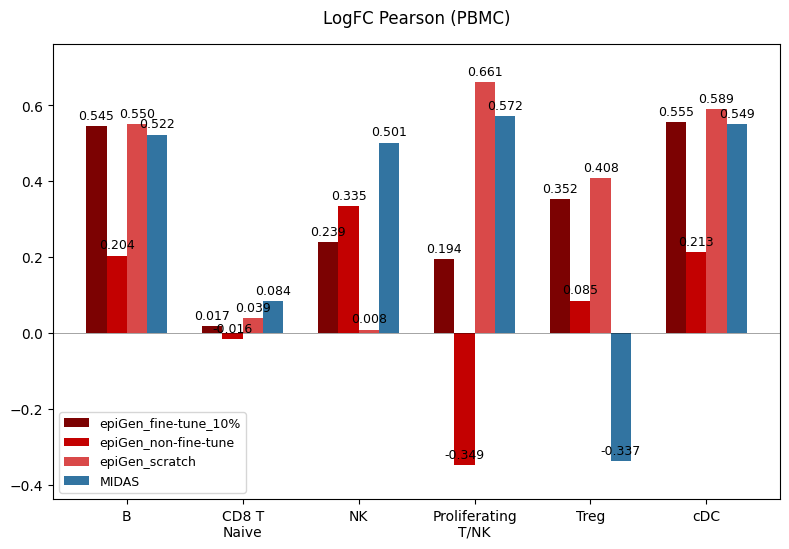

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Performance metrics (LogFC Pearson correlation) for different methods
cell_types = ['B', 'CD8 T\nNaive', 'NK', 'Proliferating\nT/NK', 'Treg', 'cDC']
epiGen_scratch = [0.5503, 0.0390, 0.0084, 0.6611, 0.4081, 0.5891]
epiGen_noff = [0.2038, -0.0159, 0.3348, -0.3489, 0.0852, 0.2129]
epiGen_ff = [0.5453, 0.0174, 0.2389, 0.1943, 0.3516, 0.5546]
MIDAS = [0.5225, 0.0841, 0.5011, 0.5715, -0.3374, 0.5492]
# Define color palette for the groups
colors = ["#7C0202", "#c30101", "#d94949", '#3274a1']

fig, ax = plt.subplots(figsize=(8, 6))

# Set x-axis positions and individual bar width
x = np.arange(len(cell_types))
width = 0.35

# Create grouped bar charts with appropriate offsets
bars1 = ax.bar(x - width*3/4, epiGen_ff, width/2, label='epiGen_fine-tune_10%', color=colors[0])
bars2 = ax.bar(x - width/4, epiGen_noff, width/2, label='epiGen_non-fine-tune', color=colors[1])
bars3 = ax.bar(x + width/4, epiGen_scratch, width/2, label='epiGen_scratch', color=colors[2])
bars4 = ax.bar(x + width*3/4, MIDAS, width/2, label='MIDAS', color=colors[3])

# Add data labels to each bar
for bar in bars1 + bars2 + bars3 + bars4:
    height = bar.get_height()
    ax.annotate(f'{height:.3f}',
                xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3),
                textcoords="offset points",
                ha='center', va='bottom',
                fontsize=9)

# Configure titles, labels, and legend
ax.set_title('LogFC Pearson (PBMC)', fontsize=12, pad=15)
ax.set_xticks(x)
ax.set_xticklabels(cell_types)
ax.legend(loc='lower left', fontsize=9)
ax.axhline(y=0, color='black', linewidth=0.5, linestyle='-', alpha=0.5)
y_min = min(min(epiGen_scratch), min(MIDAS)) - 0.1
y_max = max(max(epiGen_scratch), max(MIDAS)) + 0.1
ax.set_ylim(y_min, y_max)
ax.grid(False)
plt.tight_layout()
plt.subplots_adjust(top=0.85)
# Save the figure
plt.savefig('figures/logfc_pearson_comparison.pdf', format='pdf', dpi=300, bbox_inches='tight')
plt.show()